In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import backend as K
from tensorflow.keras.regularizers import l2

### **Cargar Datos**

In [71]:
ruta_csv = r"C:\Users\USER\OneDrive - universidadean.edu.co\2. Semestre\Seminario de investigación\Modulo 2\Modelo ML\data\processed\df_preprocesado_LSTM.csv"
df = pd.read_csv(ruta_csv, parse_dates=['FECHA_CIERRE'])

### **Preprocesamiento**

In [72]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

# Asegurar consistencia en columnas
timesteps = 10
target_col = 'ETIQUETA_MORA'

feature_cols = df.select_dtypes(include=[np.number]).columns.difference([
    target_col, 'NUMERO DE LA COLOCACION', 'MORA_SIGUIENTE']
)
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[feature_cols] = scaler.fit_transform(df_scaled[feature_cols])
df_scaled = df_scaled.sort_values(['NUMERO DE LA COLOCACION', 'FECHA_CIERRE'])

In [73]:
print(df['ETIQUETA_MORA'].value_counts(normalize=True))


ETIQUETA_MORA
0    0.698968
3    0.245222
1    0.032474
2    0.023337
Name: proportion, dtype: float64


In [74]:
feature_cols

Index(['ACIERTA', 'ANTIGUEDAD_CREDITO_MESES', 'ANTIGÜEDAD LABORAL',
       'CALIFICACION CARTERA', 'CAPITAL PEND POR FACT',
       'DIA VENCIMIENTO CUOTA', 'DIAS DE MORA', 'DIAS_CUOTA_PENDIENTE',
       'DIAS_DESDE_ULTIMO_PAGO', 'DIAS_HASTA_PROX_PAGO',
       'ESTADO CIVIL_DIVORCIADO', 'ESTADO CIVIL_RELIGIOSO',
       'ESTADO CIVIL_SEPARADO', 'ESTADO CIVIL_SIN INFORMACION',
       'ESTADO CIVIL_SOLTERO', 'ESTADO CIVIL_UNION LIBRE',
       'ESTADO CIVIL_VIUDO', 'INGRESOS', 'MARCA', 'MORA_ACTUAL',
       'NIVEL DE ESTUDIOS', 'NRO CUOTAS PAGADAS', 'NRO CUOTAS RESTANTE',
       'NRO CUOTAS VENCIDAS', 'NRO DE UTILIZACINES D', 'NRO PLAN PAGOS VIGENT',
       'NUMERO DE IDENTIFICACION DEUDOR', 'NUMERO DE PAGOS PACTA',
       'NUMERO DE PERSONAS A CARGO', 'NUMERO DEL PRODUCTO',
       'OCUPACIÓN_COMERCIANTE', 'OCUPACIÓN_OTRO',
       'OCUPACIÓN_PROFESIONAL INDEPENDIENTE', 'OCUPACIÓN_RENTISTA DE CAPITAL',
       'OCUPACIÓN_SIN INFORMACION', 'PLAZO EN DIAS', 'PRODUCTO',
       'SALDO DEL PRESTAM

### **Generación de secuencias**

In [75]:
df_scaled = df_scaled.sort_values(['NUMERO DE LA COLOCACION', 'FECHA_CIERRE'])

X_sequences, y_targets, sequence_ids = [], [], []
for _, group in df_scaled.groupby('NUMERO DE LA COLOCACION'):
    group = group.reset_index(drop=True)
    for i in range(len(group) - timesteps):
        X_seq = group.loc[i:i+timesteps-1, feature_cols].values
        y_val = group.loc[i+timesteps, target_col]
        if not np.isnan(X_seq).any() and not pd.isna(y_val):
            X_sequences.append(X_seq)
            y_targets.append(y_val)
            sequence_ids.append(group['NUMERO DE LA COLOCACION'].iloc[0])

X_lstm = np.array(X_sequences)
y_lstm = np.array(y_targets)
sequence_ids = np.array(sequence_ids)

### **División y codificación**

In [ ]:
unique_ids = np.unique(sequence_ids)
train_ids, test_ids = train_test_split(unique_ids, test_size=0.2, random_state=42)
train_mask = np.isin(sequence_ids, train_ids)
test_mask = np.isin(sequence_ids, test_ids)

X_train, X_test = X_lstm[train_mask], X_lstm[test_mask]
y_train_raw, y_test_raw = y_lstm[train_mask], y_lstm[test_mask]

y_train = to_categorical(y_train_raw, num_classes=4)
y_test = to_categorical(y_test_raw, num_classes=4)

class_weights_array = compute_class_weight(class_weight='balanced', classes=np.unique(y_lstm), y=y_lstm)
class_weights_dict = {i: w for i, w in enumerate(class_weights_array)}

### **Definición de focal loss personalizada**

In [77]:
alpha = [0.05, 2.2, 2.5, 0.1]

def focal_loss(gamma=2., alpha=alpha):
    def loss(y_true, y_pred):
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1. - epsilon)
        cross_entropy = -y_true * K.log(y_pred)
        weight = K.pow(1 - y_pred, gamma)
        fl = alpha * weight * cross_entropy
        return K.mean(K.sum(fl, axis=1))
    return loss


### **Definición del modelo**

In [78]:
model = Sequential([
    Bidirectional(LSTM(96, return_sequences=True), input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    LSTM(32),
    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.3),
    Dense(4, activation='softmax')
])


model.compile(optimizer='adam', loss=focal_loss(), metrics=['accuracy'])

c:\Users\USER\OneDrive - universidadean.edu.co\2. Semestre\Seminario de investigación\Modulo 2\Modelo ML\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### **Entrenamiento**

In [79]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
lr_reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=5, min_lr=1e-5)

# Entrenamiento
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    class_weight=class_weights_dict,
    callbacks=[early_stop, lr_reduce]
)


Epoch 1/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.3577 - loss: 0.5851 - val_accuracy: 0.4766 - val_loss: 0.3988 - learning_rate: 0.0010
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4302 - loss: 0.4032 - val_accuracy: 0.6065 - val_loss: 0.3045 - learning_rate: 0.0010
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4593 - loss: 0.3137 - val_accuracy: 0.7540 - val_loss: 0.2390 - learning_rate: 0.0010
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5501 - loss: 0.2529 - val_accuracy: 0.7625 - val_loss: 0.1895 - learning_rate: 0.0010
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5933 - loss: 0.1909 - val_accuracy: 0.7379 - val_loss: 0.1561 - learning_rate: 0.0010
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6243 - loss: 0.1568 - val_accuracy: 0.7456 - val_loss: 0.1300 - learning_rate: 0.0010
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5911 - loss: 0.1458 - 

### **Evaluación y predicción con ajuste de umbral**

In [80]:
loss, acc = model.evaluate(X_test, y_test)
print(f"\n Accuracy en test: {acc:.4f}")

52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5761 - loss: 0.0822

 Accuracy en test: 0.6213


### **Reporte de métricas y visualización**

<>:5: SyntaxWarning: invalid escape sequence '\ '
<>:5: SyntaxWarning: invalid escape sequence '\ '
C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_26220\3747374151.py:5: SyntaxWarning: invalid escape sequence '\ '
  print("\ Reporte de Clasificación:")


52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
\ Reporte de Clasificación:
                     precision    recall  f1-score   support

          0: Al día       0.98      0.49      0.65       960
      1: Entra mora       0.07      0.65      0.13        52
       2: Sale mora       0.15      0.56      0.24        45
3: Se mantiene mora       0.97      0.84      0.90       588

           accuracy                           0.62      1645
          macro avg       0.54      0.63      0.48      1645
       weighted avg       0.92      0.62      0.71      1645



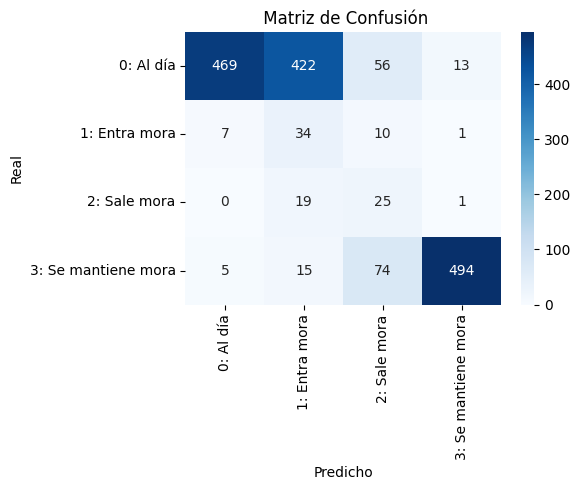

In [81]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\ Reporte de Clasificación:")
print(classification_report(y_true, y_pred, target_names=[
    "0: Al día", "1: Entra mora", "2: Sale mora", "3: Se mantiene mora"
]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["0: Al día", "1: Entra mora", "2: Sale mora", "3: Se mantiene mora"],
            yticklabels=["0: Al día", "1: Entra mora", "2: Sale mora", "3: Se mantiene mora"])
plt.title(" Matriz de Confusión")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

### **Curvas de entrenamiento**

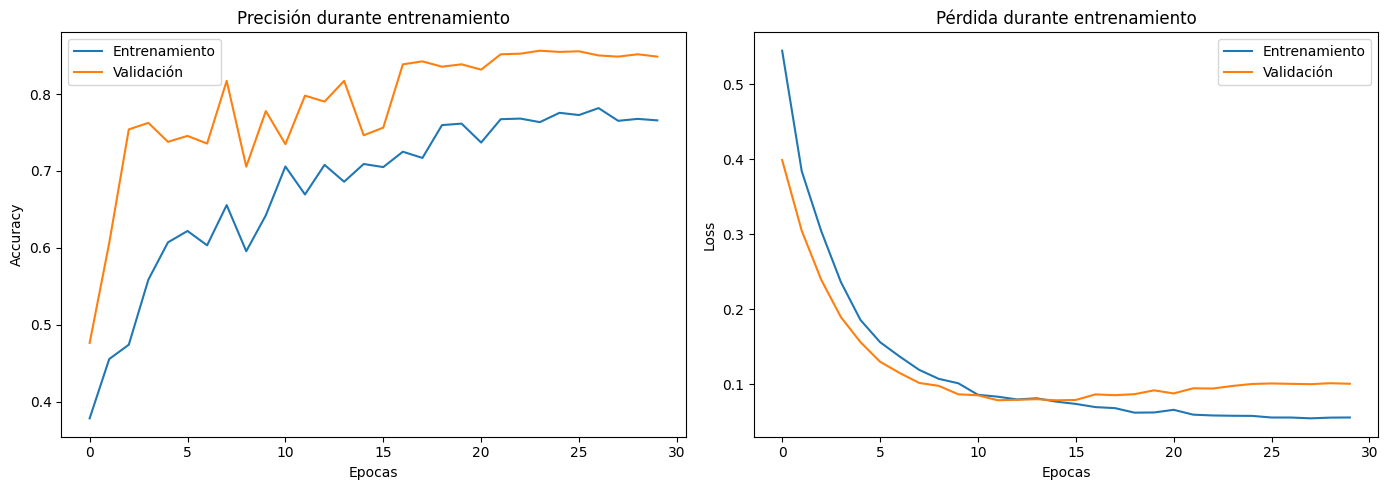

In [82]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión durante entrenamiento')
plt.xlabel('Epocas')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida durante entrenamiento')
plt.xlabel('Epocas')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


